# 🫀 Cardiovascular Risk Prediction

## 🎯 Objectif
Prédire si un patient présente un risque de maladie cardiovasculaire à partir de données médicales.

## 📊 Type de problème
- Classification binaire (0 = pas de maladie, 1 = maladie)
- Modèle utilisé : Régression logistique

## 🧠 Enjeux
La prédiction précoce permet une meilleure prévention et peut sauver des vies.


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cardio_train.csv", sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [37]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [38]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

modéfier l'age de jours à années 

In [39]:
df['age'].head()

0    18393
1    20228
2    18857
3    17623
4    17474
Name: age, dtype: int64

In [40]:
df['age'] = df['age'] / 365
df['age'].head()

0    50.391781
1    55.419178
2    51.663014
3    48.282192
4    47.873973
Name: age, dtype: float64

In [41]:
df['age'].describe()

count    70000.000000
mean        53.339358
std          6.759594
min         29.583562
25%         48.394521
50%         53.980822
75%         58.430137
max         64.967123
Name: age, dtype: float64

In [42]:
df['age'] = df['age'].astype(int)
df['age'].head()

0    50
1    55
2    51
3    48
4    47
Name: age, dtype: int64

Supprimer valeurs incohérentes

In [43]:
df[['ap_hi', 'ap_lo']].describe()

,ap_hi,ap_lo
count,70000.000000,70000.000000
mean,128.817286,96.630414
std,154.011419,188.472530
min,-150.000000,-70.000000
25%,120.000000,80.000000
50%,120.000000,80.000000
75%,140.000000,90.000000
max,16020.000000,11000.000000


J’ai identifié des valeurs physiologiquement impossibles, comme une pression diastolique négative et des valeurs de pression systolique extrêmement faibles. J’ai ensuite appliqué un filtrage basé sur des connaissances métier afin de garantir la qualité des données avant l’analyse.



In [44]:
df = df[df['ap_lo'] > 0]
df = df[df['ap_hi'] > 50]

In [45]:
df = df[df['ap_hi'] < 250]
df = df[df['ap_lo'] < 150]

In [46]:
df[['ap_hi', 'ap_lo']].describe()

,ap_hi,ap_lo
count,68782.000000,68782.000000
mean,126.612966,81.315242
std,16.744297,9.638127
min,60.000000,1.000000
25%,120.000000,80.000000
50%,120.000000,80.000000
75%,140.000000,90.000000
max,240.000000,140.000000


In [48]:
df = df[(df['height'] >= 120) & (df['height'] <= 220)]

In [50]:
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

In [51]:
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)  
df['bmi'].head()
df['bmi'].describe()


count    68725.000000
mean        27.457629
std          5.256788
min         10.726644
25%         23.875115
50%         26.346494
75%         30.116213
max        108.169847
Name: bmi, dtype: float64

In [52]:
df[df['bmi'] > 100][['height', 'weight', 'bmi']]

,height,weight,bmi
6153,122,161.0,108.169847
15366,125,167.0,106.880000


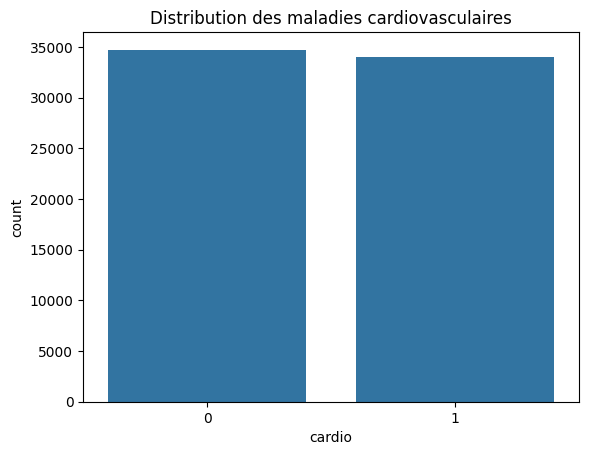

In [53]:
sns.countplot(x='cardio', data=df)
plt.title("Distribution des maladies cardiovasculaires")
plt.show()

La variable cible est équilibrée, avec un nombre similaire de personnes atteintes et non atteintes de maladies cardiovasculaires. Cela est idéal pour entraîner un modèle de classification sans avoir besoin de techniques de rééquilibrage.

Une variable cible équilibrée est idéale car elle permet au modèle d’apprendre correctement les deux classes. Cela évite qu’il soit biaisé vers une seule classe et améliore la qualité des prédictions.



<Axes: xlabel='cardio', ylabel='age'>

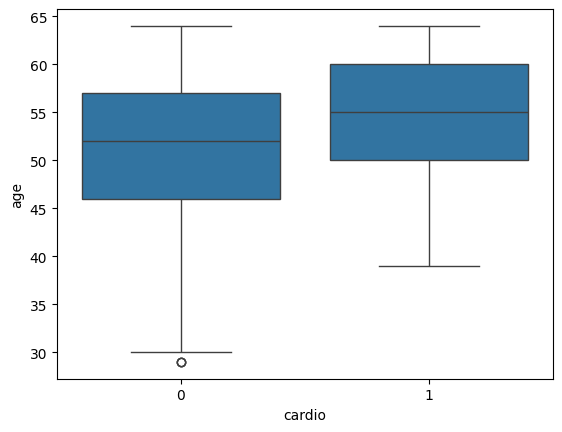

In [54]:
sns.boxplot(x='cardio', y='age', data=df)

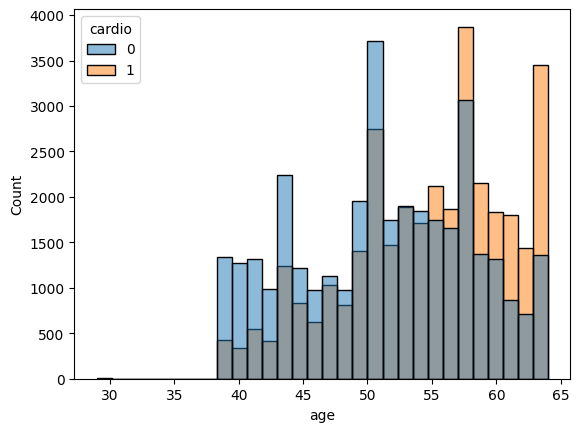

In [57]:
sns.histplot(data=df, x='age', hue='cardio', bins=30)
plt.show()

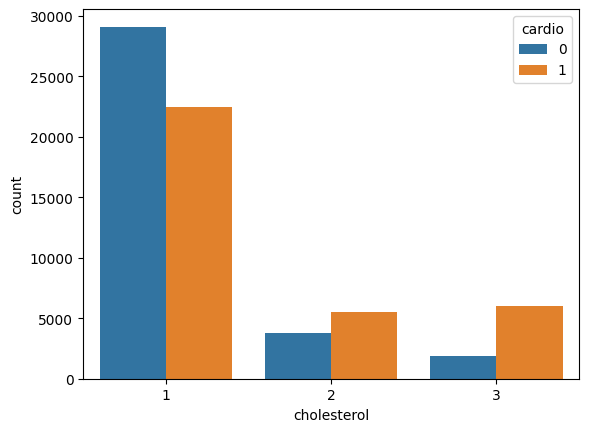

In [58]:
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.show()

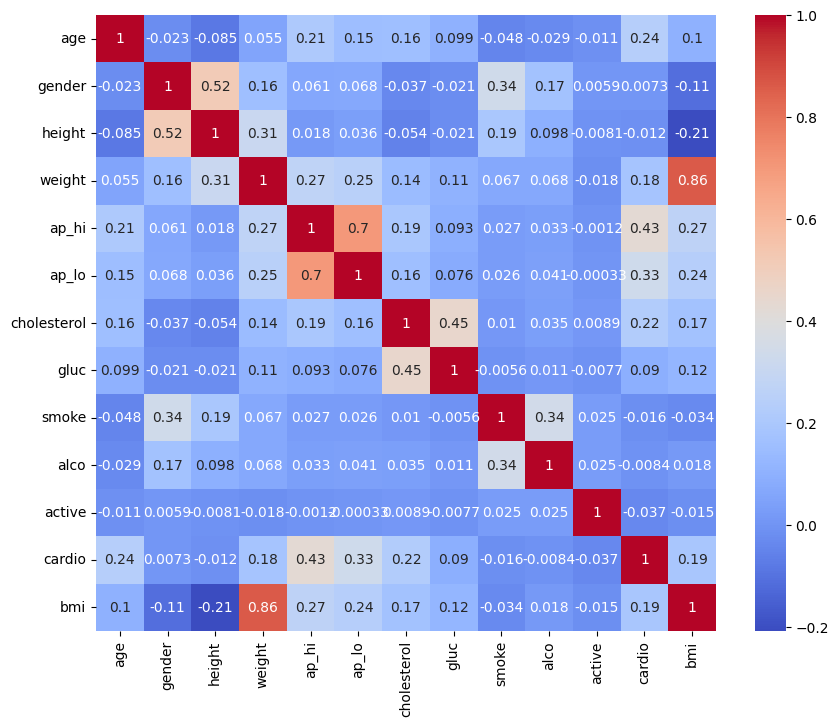

In [60]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=['id']).corr(), annot=True, cmap='coolwarm')
plt.show()

In [61]:
X = df.drop(['cardio', 'id'], axis=1)
y = df['cardio']

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [64]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [65]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[5450 1511]
 [2277 4507]]
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      6961
           1       0.75      0.66      0.70      6784

    accuracy                           0.72     13745
   macro avg       0.73      0.72      0.72     13745
weighted avg       0.73      0.72      0.72     13745



In [66]:
coefficients = pd.DataFrame(model.coef_[0], X.columns, columns=['Coefficient'])
coefficients.sort_values(by='Coefficient', ascending=False)

,Coefficient
ap_hi,0.919195
cholesterol,0.346100
age,0.345031
ap_lo,0.127183
weight,0.084003
bmi,0.071409
height,0.006047
gender,-0.008799
alco,-0.040580
smoke,-0.043322


In [68]:
arthur = pd.DataFrame([{
    'age': 53,
    'height': 175,
    'weight': 85,
    'gender': 2,
    'ap_hi': 120,
    'ap_lo': 85,
    'cholesterol': 2,
    'gluc': 1,
    'smoke': 1,
    'alco': 0,
    'active': 1,
    'bmi': 85 / (1.75**2)
}])

arthur = arthur[X.columns]

arthur_scaled = scaler.transform(arthur)

prediction = model.predict(arthur_scaled)
print("Arthur à risque ?" , prediction)

Arthur à risque ? [0]
